# 2. Silver Labels & Feature Representation

a. TFIDF
b. Dense sparse (SVD)
c. BERT embeddings

d. Review results

-> review embeddings (are these the same format?)
-> is it possible to combine a+b+c

e. Embedding Table (random walk??? try something?)
-> what is the result of this?

f. Silver Label Generation
    I. Compute cosine-similarity between review embeddings (a+b+c) and class embeddings (e)
    II. Select top-K matches, try with a simple confidence threshold

predict label based on hierarchy
label-GCN could be used need to figure this out ...

What can I do with unlabeled classes? Unmatched reviews?

g. Review results

# 3. Train a Model

a. Use generated silver labels to train a Baseline Multi-Label Classifier (same as in labs)
    I. Maybe utilize pseudolabels?


QUESTIONS:
 How can I understand what is bad with my result?


In [11]:
# Relevant imports
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from transformers import AutoTokenizer, AutoModel
import pickle
import numpy as np
import re
import random
import torch
import scipy.sparse
import scipy.sparse as sp

# Random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
CLASSES_PATH      = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH    = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH     = ROOT / "Amazon_products" / "class_related_keywords.txt"

REPRESENTATION_PATH = ROOT / "representations"
REPRESENTATION_PATH.mkdir(exist_ok=True)  # creates folder if it doesn't exist

# Paths for saved embeddings
TFIDF_PATH = REPRESENTATION_PATH / "tfidf"
TFIDF_PATH.mkdir(exist_ok=True)

SVD_PATH = REPRESENTATION_PATH / "svd_cooccurrence"
SVD_PATH.mkdir(parents=True, exist_ok=True)

BERT_PATH = REPRESENTATION_PATH / "transformer"
BERT_PATH.mkdir(exist_ok=True)

SILVER_PATH = ROOT / "silver_labels"
SILVER_PATH.mkdir(exist_ok=True)


In [ ]:
# ------------------------------
# Preprocessing
# ------------------------------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ------------------------------
# Load corpus
# ------------------------------
def load_corpus(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: preprocess_text(line.strip()) for i, line in enumerate(f)}

def load_class_keywords(path):
    class_dict = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            if ":" not in line:
                continue
            cls_raw, kws_raw = line.split(":", 1)
            cls = preprocess_text(cls_raw)
            kws = [preprocess_text(k) for k in kws_raw.split(",") if k.strip()]
            class_dict[cls] = kws
    return class_dict

# ------------------------------
# Load files
# ------------------------------
train_corpus = load_corpus(TRAIN_CORPUS_PATH)         # {id: text}
class_keywords = load_class_keywords(KEYWORDS_PATH)   # {class_name: [keywords]}

train_ids, train_texts = list(train_corpus.keys()), list(train_corpus.values())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]
keyword_names = list(class_keywords.keys())


# a. TF-IDF

In [ ]:
# ------------------------------
# TF-IDF vectorization (shared vector space)
# ------------------------------
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(train_texts + keyword_docs)

train_tfidf = vectorizer.transform(train_texts)
keyword_tfidf = vectorizer.transform(keyword_docs)

"""
# Create vectors
vectorizer = TfidfVectorizer(
    max_features=20000,  # limit vocabulary size for memory
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=5,            # ignore very rare tokens
    max_df=0.9           # ignore very common tokens
)
"""

# ------------------------------
# Compute cosine similarity
# ------------------------------
similarity_matrix_tfidf = cosine_similarity(train_tfidf, keyword_tfidf)
# shape: (num_train_docs, num_classes)

# ------------------------------
# Generate silver labels
# ------------------------------
import numpy as np

k = 3  # top-k classes
confidence_threshold = 0.5  # only include classes above this similarity

silver_labels_tfidf = []

for i, sims in enumerate(similarity_matrix_tfidf):
    # Get indices of top k similarities (sorted descending)
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]

    if not top_classes:
        # No class above threshold
        silver_labels_tfidf.append((train_ids[i], []))
    else:
        silver_labels_tfidf.append((train_ids[i], top_classes))

# ------------------------------
# Inspect first 10 entries
# ------------------------------
for entry in silver_labels_tfidf[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

# ------------------------------
# Save vectorizer and TF-IDF matrices
# ------------------------------
with open(TFIDF_PATH / "vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

scipy.sparse.save_npz(TFIDF_PATH / "X_train_tfidf.npz", train_tfidf)
scipy.sparse.save_npz(TFIDF_PATH / "X_keywords_tfidf.npz", keyword_tfidf)

print("[Done] Saved TF-IDF matrices and vectorizer.")
print("[Done] Generated silver labels for", len(silver_labels_tfidf), "products.")

Product 0: [('stress reduction', 0.20007237890523077)]
Product 1: []
Product 2: [('granola bars', 0.33764856457958414), ('bars', 0.3342822936726832), ('breakfast cereal bars', 0.28141123148531966)]
Product 3: [('styling products', 0.24723692779189405), ('hair care', 0.22414740454601703)]
Product 4: []
Product 5: []
Product 6: [('stacking blocks', 0.20841921658572465)]
Product 7: [('cameras camcorders', 0.4217482284103575), ('household batteries', 0.3484761827407604)]
Product 8: [('feeding', 0.41912269847736894), ('feeding watering supplies', 0.3538338771836884)]
Product 9: [('apparel accessories', 0.22451177680034914)]
[Done] Saved TF-IDF matrices and vectorizer.
[Done] Generated silver labels for 29487 products.


# b Dense Static Representation
   - Technique 1: Dimensionality Reduction (Truncated SVD on co-occurrence matrix)
This option creates dense word embeddings by:

Building a word–word co-occurrence matrix

Applying Truncated SVD to obtain dense word vectors

Aggregating word vectors into document vectors for:

each training product description

each class keyword doc

Comparing them (cosine similarity)

Generating silver labels

This yields a static embedding space that is often better than TF-IDF and lighter than models like word2vec.

In [ ]:
# ---------- load data ----------
print("Loading corpus and keywords...")
train_corpus = load_corpus(TRAIN_CORPUS_PATH)         # {id: text}
class_keywords = load_class_keywords(KEYWORDS_PATH)   # {class_name: [keywords]}

train_ids, train_texts = list(train_corpus.keys()), list(train_corpus.values())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]
keyword_names = list(class_keywords.keys())

# ---------- params ----------
TOP_VOCAB = 20000      # limit vocab to top-N frequent tokens (adjustable)
WINDOW_SIZE = 4        # symmetric context window
SVD_DIM = 300          # embedding dimension (adjustable)
MIN_FREQ = 2           # min token freq to be included
K = 3                  # top-k classes to keep per product
CONF_THRESH = 0.5      # similarity threshold for silver label

# ---------- build vocabulary (token -> idx) ----------
print("Building vocabulary (top {})...".format(TOP_VOCAB))
token_counter = Counter()
def tokenize(text):
    return text.split() if text else []

# collect tokens from train texts and keywords
for txt in train_texts:
    token_counter.update(tokenize(txt))
for txt in keyword_docs:
    token_counter.update(tokenize(txt))

# filter by min frequency then take top TOP_VOCAB
filtered = [(tok, cnt) for tok, cnt in token_counter.items() if cnt >= MIN_FREQ]
filtered.sort(key=lambda x: x[1], reverse=True)
vocab_tokens = [tok for tok, _ in filtered[:TOP_VOCAB]]
vocab_set = set(vocab_tokens)
vocab = {tok: i for i, tok in enumerate(vocab_tokens)}
V = len(vocab)
print("Vocabulary size:", V)

# ---------- build sparse co-occurrence matrix ----------
# We will accumulate COO data: rows, cols, data
print("Building co-occurrence counts with window size", WINDOW_SIZE)
rows = []
cols = []
data = []

# Use dictionary of dicts to accumulate counts in memory-efficient way if V small/medium
# For larger V, build lists and convert to sparse COO
cooc = defaultdict(Counter)  # cooc[i][j] = count

for idx, txt in enumerate(train_texts):
    toks = [t for t in tokenize(txt) if t in vocab_set]
    L = len(toks)
    for i, tok in enumerate(toks):
        wi = vocab[tok]
        # window
        start = max(0, i - WINDOW_SIZE)
        end = min(L, i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if j == i:
                continue
            tj = toks[j]
            wj = vocab[tj]
            cooc[wi][wj] += 1

# Convert cooc to COO lists
for i, neigh in cooc.items():
    for j, cnt in neigh.items():
        rows.append(i)
        cols.append(j)
        data.append(cnt)

# Build sparse matrix (V x V)
C = sp.coo_matrix((data, (rows, cols)), shape=(V, V), dtype=np.float32)
C = C.tocsr()
print("Co-occurrence matrix built. nnz =", C.nnz)

# ---------- Apply Truncated SVD ----------
print("Running TruncatedSVD (n_components={})...".format(SVD_DIM))
svd = TruncatedSVD(n_components=SVD_DIM, n_iter=10, random_state=42)
# TruncatedSVD accepts sparse input
word_embeddings = svd.fit_transform(C)  # shape: (V, d)
print("SVD done. word_embeddings shape:", word_embeddings.shape)

# Optionally normalize embeddings (helps cosine similarity)
def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

word_embeddings = l2_normalize_rows(word_embeddings)

# Save svd model and word embeddings
with open(SVD_PATH / "svd_model.pkl", "wb") as f:
    pickle.dump(svd, f)
np.save(SVD_PATH / "word_embeddings.npy", word_embeddings)
with open(SVD_PATH / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
print("Saved SVD model, word embeddings and vocab to:", SVD_PATH)

# ---------- Helper: compute document embedding by weighted average of word vectors ----------
def doc_to_embedding(text, word_embeddings, vocab, use_tf_weights=True):
    toks = [t for t in tokenize(text) if t in vocab]
    if not toks:
        return np.zeros((word_embeddings.shape[1],), dtype=np.float32)
    counts = Counter(toks)
    # weights: simple TF (count) normalized
    if use_tf_weights:
        total = sum(counts.values())
        emb = np.zeros((word_embeddings.shape[1],), dtype=np.float32)
        for tok, cnt in counts.items():
            emb += (cnt / total) * word_embeddings[vocab[tok]]
        return emb
    else:
        # simple mean
        vecs = [word_embeddings[vocab[t]] for t in toks]
        return np.mean(vecs, axis=0)

# ---------- convert all training docs and keyword docs to dense vectors ----------
print("Aggregating word embeddings -> document embeddings for train corpus...")
train_dense = np.zeros((len(train_texts), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(train_texts):
    train_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)

print("Aggregating word embeddings -> keyword embeddings...")
keyword_dense = np.zeros((len(keyword_docs), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(keyword_docs):
    keyword_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)

# normalize rows for cosine similarity
train_dense = l2_normalize_rows(train_dense)
keyword_dense = l2_normalize_rows(keyword_dense)

# ---------- Compute cosine similarities and generate silver labels ----------
print("Computing cosine similarities and building silver labels...")
similarity_matrix_svd = cosine_similarity(train_dense, keyword_dense)  # shape (num_train, num_classes)

silver_labels_svd = []
for i, sims in enumerate(similarity_matrix_svd):
    top_indices = sims.argsort()[::-1][:K]
    top_classes = [(keyword_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= CONF_THRESH]
    if not top_classes:
        silver_labels_svd.append((train_ids[i], []))
    else:
        silver_labels_svd.append((train_ids[i], top_classes))

# Inspect first 10
for entry in silver_labels_svd[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

# ---------- Save outputs ----------
import scipy
from scipy import sparse

scipy.sparse.save_npz(SVD_PATH / "X_train_svd.npz", sp.csr_matrix(train_dense))
scipy.sparse.save_npz(SVD_PATH / "X_keywords_svd.npz", sp.csr_matrix(keyword_dense))

with open(SVD_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)

print("[Done] Saved train/keyword embeddings and silver labels. Generated silver labels for", len(silver_labels_svd), "products.")

Loading corpus and keywords...
Building vocabulary (top 20000)...
Vocabulary size: 20000
Building co-occurrence counts with window size 4
Co-occurrence matrix built. nnz = 3515732
Running TruncatedSVD (n_components=300)...
SVD done. word_embeddings shape: (20000, 300)
Saved SVD model, word embeddings and vocab to: project_release/representations/svd_cooccurrence
Aggregating word embeddings -> document embeddings for train corpus...
Aggregating word embeddings -> keyword embeddings...
Computing cosine similarities and building silver labels...
Product 0: [('health monitors', 0.9758671522140503), ('basic life skills toys', 0.9664862155914307), ('eye care', 0.9634793996810913)]
Product 1: [('laundry', 0.97559654712677), ('bubble bath', 0.9728456139564514), ('aquarium d cor', 0.9726720452308655)]
Product 2: [('eye care', 0.9669040441513062), ('personal care', 0.9651252031326294), ('deodorants antiperspirants', 0.9641223549842834)]
Product 3: [('hair color', 0.9672929048538208), ('personal 

# c. BERT

In [ ]:
# --- Load BERT model ---
model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# --- Function to embed texts with progress feedback ---
def embed_texts(texts, batch_size=32):
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch_num = i // batch_size + 1
        print(f"[INFO] Encoding batch {batch_num}/{total_batches}", end="\r")
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            # mean pooling of last hidden state
            batch_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(batch_embeddings.cpu().numpy())
    print()  # newline after last batch
    return np.vstack(embeddings)

# HAVE LOWERED BATCH SIZE FROM 64
# --- Compute embeddings ---
print("[INFO] Computing train embeddings...")
train_embeddings = embed_texts(train_texts, batch_size=64)

print("[INFO] Computing keyword embeddings...")
keyword_embeddings = embed_texts(keyword_docs, batch_size=64)

# --- Compute cosine similarity ---
print("[INFO] Computing cosine similarity matrix...")
similarity_matrix_bert = cosine_similarity(train_embeddings, keyword_embeddings)

# --- Generate silver labels using top-k with progress feedback ---
k = 3
confidence_threshold = 0.5
silver_labels_bert = []

total_products = len(train_ids)
for i, sims in enumerate(similarity_matrix_bert):
    if i % 100 == 0:
        print(f"[INFO] Processing product {i+1}/{total_products}", end="\r")
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]
    silver_labels_bert.append((train_ids[i], top_classes if top_classes else []))
print()  # newline after last product

# --- Save silver labels ---
with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)

print("[DONE] Generated SVD/BERT silver labels for", len(silver_labels_bert), "products.")


[INFO] Computing train embeddings...
[INFO] Encoding batch 5/461

KeyboardInterrupt: 

# d. Review

In [21]:
# First simple sanity check 

def show_top_silver_examples(silver_labels, train_texts, min_conf=0.6, top_n=5):
    """
    silver_labels: list of (pid, [(class_name, score), ...])
    train_texts: list of raw review/product texts
    min_conf: minimum similarity to display
    top_n: number of examples to show
    """
    # flatten all predictions to (pid, class_name, score)
    flattened = []
    for pid, cls_list in silver_labels:
        for cls_name, score in cls_list:
            flattened.append((pid, cls_name, float(score)))

    # filter by confidence
    filtered = [x for x in flattened if x[2] >= min_conf]
    filtered_sorted = sorted(filtered, key=lambda x: x[2], reverse=True)

    print(f"\nShowing top {top_n} examples with confidence >= {min_conf}:\n")
    for pid, cls, score in filtered_sorted[:top_n]:
        print("\n=====================================================")
        print(f"Review ID: {pid}")
        print(f"Confidence: {score:.4f}")
        print(f"Predicted class: {cls}")
        print("\nReview text:")
        print(train_texts[pid])

# For TF-IDF silver labels
show_top_silver_examples(silver_labels_tfidf, train_texts, min_conf=0.6, top_n=5)

# For SVD silver labels
show_top_silver_examples(silver_labels_svd, train_texts, min_conf=0.6, top_n=5)

# For BERT silver labels
show_top_silver_examples(silver_labels_bert, train_texts, min_conf=0.6, top_n=5)




Showing top 5 examples with confidence >= 0.6:


Review ID: 29048
Confidence: 0.8489
Predicted class: kites wind spinners

Review text:
29048 go fly a kite skywinder 30 x500 we love the go fly a kite kite winder it is easy but not too easy to take the fun out of flying a kite a

Review ID: 23556
Confidence: 0.8170
Predicted class: kites wind spinners

Review text:
23556 kite spool 90 lb test assorted colors like any hobby it takes a while to get the hang of using a kite and the kite string can be an issue this kite string was perfect for my kite and winding and unwinding is not hard to do good quality string well packaged and the clip is very good

Review ID: 27577
Confidence: 0.8125
Predicted class: sauces

Review text:
27577 bone suckin sauce sauce s the sauce a good taste sweet with a hint of heat just wished it was a thicker sauce to me it is more of a marinate

Review ID: 5183
Confidence: 0.8075
Predicted class: seafood

Review text:
5183 sushi chef sushi making kit i had always 

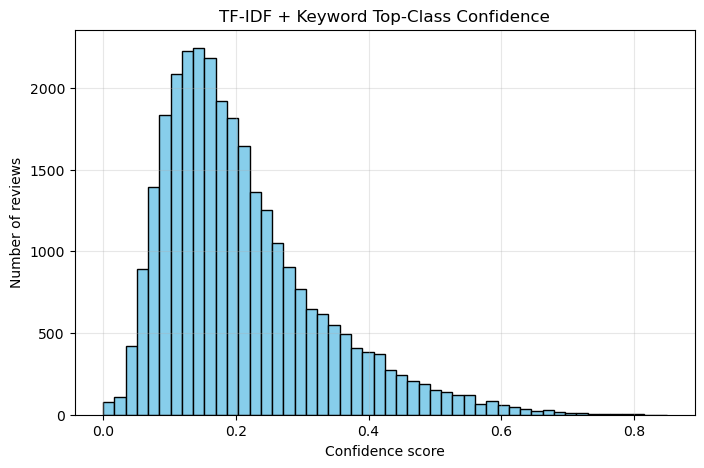

Confidence percentiles: [0.08547794 0.12292037 0.18133797 0.26452902 0.37624693]


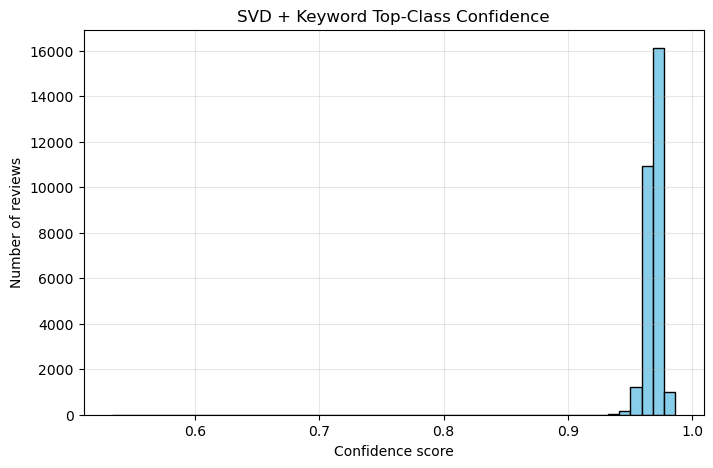

Confidence percentiles: [0.96203716 0.96581051 0.96922791 0.97234675 0.97505002]


'\n# BERT\nmax_conf_bert = plot_top_confidence_distribution(\n    similarity_matrix_bert, \n    title="BERT + Keyword Top-Class Confidence"\n)\n'

In [23]:
# Plot confidence distributions

import numpy as np
import matplotlib.pyplot as plt

def plot_top_confidence_distribution(similarity_matrix, title="Top-Class Confidence Distribution", bins=50, percentiles=[10,25,50,75,90]):
    """
    similarity_matrix: numpy array or sparse matrix of shape (num_reviews, num_classes)
    title: plot title
    bins: number of bins for histogram
    percentiles: list of percentiles to print
    """
    # Convert sparse matrix to dense if needed
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    # Take max confidence per review
    max_conf_per_review = sim_dense.max(axis=1)

    # Plot histogram
    plt.figure(figsize=(8,5))
    plt.hist(max_conf_per_review, bins=bins, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Confidence score")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    # Print percentiles
    print("Confidence percentiles:", np.percentile(max_conf_per_review, percentiles))
    return max_conf_per_review

# TF-IDF
max_conf_tfidf = plot_top_confidence_distribution(
    similarity_matrix_tfidf, 
    title="TF-IDF + Keyword Top-Class Confidence"
)

# SVD
max_conf_svd = plot_top_confidence_distribution(
    similarity_matrix_svd, 
    title="SVD + Keyword Top-Class Confidence"
)
"""
# BERT
max_conf_bert = plot_top_confidence_distribution(
    similarity_matrix_bert, 
    title="BERT + Keyword Top-Class Confidence"
)
"""


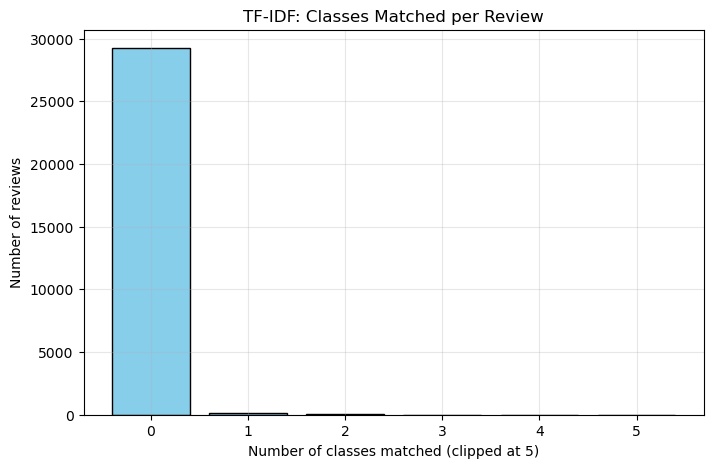

0 classes: 29250 reviews
1 classes: 152 reviews
2 classes: 81 reviews
3 classes: 4 reviews
4 classes: 0 reviews
5 classes: 0 reviews


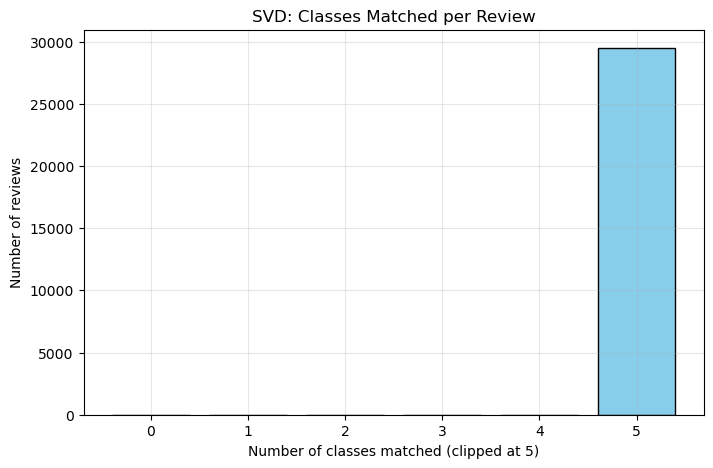

0 classes: 1 reviews
1 classes: 2 reviews
2 classes: 0 reviews
3 classes: 1 reviews
4 classes: 0 reviews
5 classes: 29483 reviews


NameError: name 'similarity_matrix_bert' is not defined

In [24]:
# How many classes per review

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def plot_classes_per_review(similarity_matrix, min_conf=0.6, clip_max=5, title=None):
    """
    similarity_matrix: np.array or sparse matrix (num_reviews x num_classes)
    min_conf: confidence threshold to consider a class “matched”
    clip_max: maximum number of classes to display per review
    title: plot title
    """
    # Convert sparse to dense if needed
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    # Count number of classes per review above threshold
    num_classes_per_review = (sim_dense >= min_conf).sum(axis=1)
    num_classes_per_review_clipped = np.clip(num_classes_per_review, 0, clip_max)

    # Get counts
    counter = Counter(num_classes_per_review_clipped)
    counts = [counter.get(i, 0) for i in range(clip_max+1)]

    # Plot
    plt.figure(figsize=(8,5))
    plt.bar(range(clip_max+1), counts, color='skyblue', edgecolor='black')
    plt.xticks(range(clip_max+1))
    plt.title(title or f"Number of Classes per Review (conf >= {min_conf})")
    plt.xlabel(f"Number of classes matched (clipped at {clip_max})")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    # Print stats
    for i, c in enumerate(counts):
        print(f"{i} classes: {c} reviews")

    return num_classes_per_review_clipped

# TF-IDF
num_classes_tfidf = plot_classes_per_review(
    similarity_matrix_tfidf, 
    min_conf=0.6, 
    clip_max=5, 
    title="TF-IDF: Classes Matched per Review"
)

# SVD
num_classes_svd = plot_classes_per_review(
    similarity_matrix_svd, 
    min_conf=0.6, 
    clip_max=5, 
    title="SVD: Classes Matched per Review"
)

# BERT
num_classes_bert = plot_classes_per_review(
    similarity_matrix_bert, 
    min_conf=0.6, 
    clip_max=5, 
    title="BERT: Classes Matched per Review"
)


# e. Embedding Table

In [ ]:
# ------------------------------
# Class Embedding Table
# ------------------------------
CLASS_EMB_PATH = REPRESENTATION_PATH / "class_embeddings"
CLASS_EMB_PATH.mkdir(exist_ok=True)

# ---------- Load classes and keywords ----------
print("[INFO] Loading classes and keywords...")
class_keywords = load_class_keywords(KEYWORDS_PATH)   # {class_name: [keywords]}
class_names = list(class_keywords.keys())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]

# ---------- Build initial text features ----------
# Simple option: use TF-IDF vectorization for class embeddings
from sklearn.feature_extraction.text import TfidfVectorizer

print("[INFO] Building TF-IDF vectorizer for classes...")
class_vectorizer = TfidfVectorizer(max_features=5000)
class_vectorizer.fit(keyword_docs)
class_tfidf = class_vectorizer.transform(keyword_docs)  # sparse (num_classes x vocab)

# ---------- Optional: Dimensionality reduction ----------
from sklearn.decomposition import TruncatedSVD

SVD_DIM_CLASS = 128  # embedding dimension for class embeddings
print(f"[INFO] Reducing class TF-IDF to {SVD_DIM_CLASS} dimensions with TruncatedSVD...")
svd_class = TruncatedSVD(n_components=SVD_DIM_CLASS, n_iter=10, random_state=42)
class_dense = svd_class.fit_transform(class_tfidf)  # shape: (num_classes, SVD_DIM_CLASS)

# Normalize embeddings
def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

class_dense = l2_normalize_rows(class_dense)

# ---------- Save class embeddings ----------
np.save(CLASS_EMB_PATH / "class_embeddings.npy", class_dense)
with open(CLASS_EMB_PATH / "class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)
with open(CLASS_EMB_PATH / "class_vectorizer.pkl", "wb") as f:
    pickle.dump(class_vectorizer, f)
with open(CLASS_EMB_PATH / "svd_class_model.pkl", "wb") as f:
    pickle.dump(svd_class, f)

print(f"[DONE] Saved class embeddings for {len(class_names)} classes at {CLASS_EMB_PATH}")


# f. Silver Labels

## Techniques in isolation first

Just to get an idea for how they perform in isolation

In [ ]:
# ------------------------------
# Reusable silver label generator function
# ------------------------------
def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    """
    review_embeddings: np.array (num_reviews, emb_dim) - TF-IDF, SVD, or BERT
    class_embeddings: np.array (num_classes, emb_dim)
    review_ids: list of review IDs
    class_names: list of class names (length = num_classes)
    top_k: select top-K classes
    conf_thresh: minimum similarity to include class
    """
    # Normalize embeddings for cosine similarity
    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)
    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)
    
    # Compute similarity matrix
    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    
    # Generate top-K silver labels
    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        top_indices = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes if top_classes else []))
        
    return silver_labels

# ------------------------------
# Load class embeddings
# ------------------------------
class_dense = np.load(CLASS_EMB_PATH / "class_embeddings.npy")
with open(CLASS_EMB_PATH / "class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

# ------------------------------
# Generate silver labels individually
# ------------------------------
# TF-IDF
silver_labels_tfidf_class = generate_silver_labels(train_tfidf.toarray(), class_dense, train_ids, class_names)

# SVD
silver_labels_svd_class = generate_silver_labels(train_dense, class_dense, train_ids, class_names)

# BERT
silver_labels_bert_class = generate_silver_labels(train_embeddings, class_dense, train_ids, class_names)

# ------------------------------
# Save results
# ------------------------------
with open(SILVER_PATH / "silver_labels_tfidf_class.pkl", "wb") as f:
    pickle.dump(silver_labels_tfidf_class, f)

with open(SILVER_PATH / "silver_labels_svd_class.pkl", "wb") as f:
    pickle.dump(silver_labels_svd_class, f)

with open(SILVER_PATH / "silver_labels_bert_class.pkl", "wb") as f:
    pickle.dump(silver_labels_bert_class, f)

print("[DONE] Generated silver labels for TF-IDF, SVD, and BERT embeddings using class embedding table.")


## Hybrid Labels

In [ ]:
# ------------------------------
# Parameters
# ------------------------------
TOP_K = 3
CONF_THRESH = 0.6
WEIGHTS = [0.3, 0.3, 0.4]  # TF-IDF, SVD, BERT
CONF_THRESH_COMB = 0.6

# ------------------------------
# Reusable silver label function
# ------------------------------
def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)
    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)
    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    
    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        top_indices = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes if top_classes else []))
    return silver_labels, sim_matrix

# ------------------------------
# Compute individual silver labels
# ------------------------------
silver_tfidf, sim_tfidf = generate_silver_labels(train_tfidf.toarray(), class_dense, train_ids, class_names, TOP_K, CONF_THRESH)
silver_svd, sim_svd     = generate_silver_labels(train_dense, class_dense, train_ids, class_names, TOP_K, CONF_THRESH)
silver_bert, sim_bert   = generate_silver_labels(train_embeddings, class_dense, train_ids, class_names, TOP_K, CONF_THRESH)

# ------------------------------
# 1. Union of all three
# ------------------------------
union_labels = []
for i in range(len(train_ids)):
    label_set = {}
    for silver_labels in [silver_tfidf, silver_svd, silver_bert]:
        for cls, score in silver_labels[i][1]:
            if cls not in label_set or score > label_set[cls]:
                label_set[cls] = score
    sorted_labels = sorted(label_set.items(), key=lambda x: x[1], reverse=True)
    union_labels.append((train_ids[i], sorted_labels[:TOP_K]))

# ------------------------------
# 2. Weighted average
# ------------------------------
weighted_labels = []
for i in range(len(train_ids)):
    score_dict = defaultdict(float)
    for weight, silver_labels in zip(WEIGHTS, [silver_tfidf, silver_svd, silver_bert]):
        for cls, score in silver_labels[i][1]:
            score_dict[cls] += weight * score
    sorted_labels = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    weighted_labels.append((train_ids[i], sorted_labels[:TOP_K]))

# ------------------------------
# 3. Threshold-based ensemble
# ------------------------------
threshold_labels = []
for i in range(len(train_ids)):
    score_dict = defaultdict(float)
    for silver_labels in [silver_tfidf, silver_svd, silver_bert]:
        for cls, score in silver_labels[i][1]:
            score_dict[cls] = max(score_dict.get(cls, 0), score)
    filtered = [(cls, s) for cls, s in score_dict.items() if s >= CONF_THRESH_COMB]
    sorted_labels = sorted(filtered, key=lambda x: x[1], reverse=True)
    threshold_labels.append((train_ids[i], sorted_labels))

# ------------------------------
# Save results
# ------------------------------
with open(SILVER_PATH / "silver_labels_union.pkl", "wb") as f:
    pickle.dump(union_labels, f)

with open(SILVER_PATH / "silver_labels_weighted.pkl", "wb") as f:
    pickle.dump(weighted_labels, f)

with open(SILVER_PATH / "silver_labels_threshold.pkl", "wb") as f:
    pickle.dump(threshold_labels, f)

print("[DONE] Generated hybrid silver labels (union, weighted, threshold) for all reviews.")


# Review

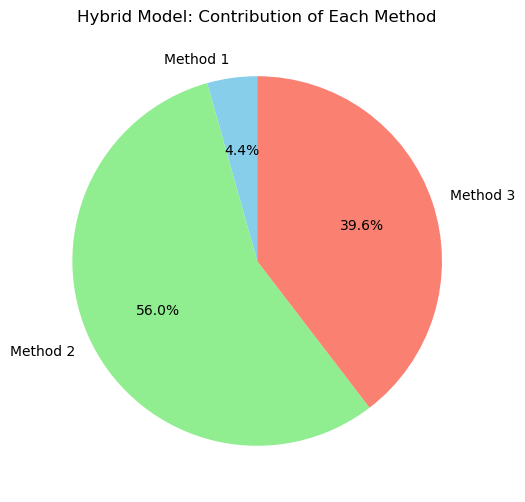

Method 1: 4.4%
Method 2: 56.0%
Method 3: 39.6%


In [ ]:
# ------------------------------
# Visualize contributions for hybrid sets
# ------------------------------
def plot_hybrid_contributions(hybrid_label_sets, original_methods, method_weights=None, top_k=3):
    """
    hybrid_label_sets: dict of {name: hybrid_labels}, e.g., {"Union": union_labels, ...}
    original_methods: list of original silver label sets [TF-IDF, SVD, BERT]
    method_weights: optional weights for original methods
    top_k: how many top labels to consider per method
    """
    num_methods = len(original_methods)
    if method_weights is None:
        method_weights = [1.0] * num_methods
    method_names = ["TF-IDF", "SVD", "BERT"]

    for hybrid_name, hybrid_labels in hybrid_label_sets.items():
        contribution = defaultdict(float)
        for method_idx, method_labels in enumerate(original_methods):
            weight = method_weights[method_idx]
            # Count how many times a label from this method appears in the hybrid
            for i in range(len(hybrid_labels)):
                hybrid_classes = set([cls for cls, _ in hybrid_labels[i][1][:top_k]])
                method_classes = set([cls for cls, _ in method_labels[i][1][:top_k]])
                # Intersection = this method contributed to hybrid
                contribution[method_idx] += len(hybrid_classes & method_classes) * weight

        # Normalize
        total = sum(contribution.values())
        percentages = [100 * contribution[i]/total for i in range(num_methods)]

        # Plot pie chart
        plt.figure(figsize=(6,6))
        plt.pie(percentages, labels=method_names, autopct="%1.1f%%", startangle=90,
                colors=['skyblue','lightgreen','salmon'])
        plt.title(f"{hybrid_name} Hybrid: Method Contribution")
        plt.show()

        # Print numbers
        print(f"{hybrid_name} Hybrid Contribution:")
        for i, pct in enumerate(percentages):
            print(f"{method_names[i]}: {pct:.1f}%")
        print("\n")

# ------------------------------
# Call function for the three hybrids
# ------------------------------
plot_hybrid_contributions(
    hybrid_label_sets={
        "Union": union_labels,
        "Weighted": weighted_labels,
        "Threshold": threshold_labels
    },
    original_methods=[silver_tfidf, silver_svd, silver_bert],
    method_weights=[1.0, 1.0, 1.0],
    top_k=TOP_K
)


In [ ]:
import pickle
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np

# ------------------------------
# Load hybrid silver labels
# ------------------------------
HYBRID_PATH = SILVER_PATH  # adjust if different
with open(HYBRID_PATH / "union_labels.pkl", "rb") as f:
    union_labels = pickle.load(f)
with open(HYBRID_PATH / "weighted_labels.pkl", "rb") as f:
    weighted_labels = pickle.load(f)
with open(HYBRID_PATH / "threshold_labels.pkl", "rb") as f:
    threshold_labels = pickle.load(f)

hybrids = {
    "Union": union_labels,
    "Weighted": weighted_labels,
    "Threshold": threshold_labels
}

# ------------------------------
# Load class hierarchy if needed for hierarchy coverage
# ------------------------------
hierarchy_path = HIERARCHY_PATH
parents_map = defaultdict(list)  # child -> parents

with open(hierarchy_path, "r", encoding="utf8") as f:
    for line in f:
        if "<" not in line:
            continue
        parent, child = [x.strip() for x in line.strip().split("<")]
        parents_map[child].append(parent)

# ------------------------------
# Diagnostic functions
# ------------------------------

def plot_label_distribution(silver_labels, top_n=20, title="Label Distribution"):
    all_labels = [cls for pid, labels in silver_labels for cls, _ in labels]
    counter = Counter(all_labels)
    top_items = counter.most_common(top_n)
    labels, counts = zip(*top_items) if top_items else ([], [])
    
    plt.figure(figsize=(12,5))
    plt.bar(labels, counts, color='skyblue')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()

def plot_labels_per_review(silver_labels, title="Labels per Review"):
    counts = [len(labels) for pid, labels in silver_labels]
    plt.figure(figsize=(6,4))
    plt.hist(counts, bins=range(0, max(counts)+2), color='salmon', edgecolor='black')
    plt.xlabel("Number of Labels")
    plt.ylabel("Number of Reviews")
    plt.title(title)
    plt.show()

def plot_confidence_scores(silver_labels, title="Label Confidence Distribution"):
    scores = [score for pid, labels in silver_labels for cls, score in labels]
    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=30, color='lightgreen', edgecolor='black')
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

def compute_hierarchy_coverage(silver_labels, parents_map):
    total = 0
    covered_parents = set()
    for pid, labels in silver_labels:
        for cls, _ in labels:
            parents = parents_map.get(cls, [])
            covered_parents.update(parents)
            total += len(parents)
    print(f"Total parent links covered: {len(covered_parents)} / {total if total>0 else 1}")

# ------------------------------
# Run diagnostics for each hybrid
# ------------------------------
for name, labels in hybrids.items():
    print(f"\n=== Diagnostics for {name} Hybrid ===")
    plot_label_distribution(labels, top_n=20, title=f"{name} Hybrid: Top-20 Label Distribution")
    plot_labels_per_review(labels, title=f"{name} Hybrid: Labels per Review")
    plot_confidence_scores(labels, title=f"{name} Hybrid: Confidence Score Distribution")
    compute_hierarchy_coverage(labels, parents_map)
